In [26]:
#Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# Load data set
url = "https://raw.githubusercontent.com/hirandharmarathna/sales-prediction-ai/main/data/raw/jewelry_sales_raw.csv"
df = pd.read_csv(url, header=None, skiprows=1)

# Manually assign the correct column names in order
df.columns = [
    "purchase_date","transaction_id","product_id","quantity","category_id","category",
    "gender","price_usd","customer_id","color_code","color","metal","gem"]


print("Dataset loaded successfully!")
print("Initial shape:", df.shape)

Dataset loaded successfully!
Initial shape: (95911, 13)


In [28]:
#Convert Data Types

# Convert purchase_date to datetime (timezone aware)
df["purchase_date"] = pd.to_datetime(df["purchase_date"], utc=True)

# Convert quantity to integer
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").astype("Int64")


print("Data types fixed")
print(df.dtypes)
print()


Data types fixed
purchase_date     datetime64[ns, UTC]
transaction_id                  int64
product_id                      int64
quantity                        Int64
category_id                   float64
category                       object
gender                        float64
price_usd                     float64
customer_id                   float64
color_code                     object
color                          object
metal                          object
gem                            object
dtype: object



In [29]:
#Clean Category Values

df["category"] = df["category"].str.replace("jewelry.", "", regex=False)

print("Category values cleaned")
print()
print("Unique categories:", df["category"].value_counts())



Category values cleaned

Unique categories: category
earring     29052
ring        28300
pendant     13088
bracelet     6188
0.00         4392
            ...  
916.44          1
1829.37         1
132.53          1
75.76           1
253.77          1
Name: count, Length: 218, dtype: int64


In [30]:
# Handle Missing Values
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())
print()

# Fill missing price_usd with the mean price of that specific category
df["price_usd"] = df.groupby("category")["price_usd"].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing text columns with the most common value (mode)
categorical_columns = ["color", "metal", "gem", "color_code", "category"]

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing gender with the most common value
if df["gender"].isnull().sum() > 0:
    df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

# Drop any remaining rows that still have missing values
df = df.dropna()

print("Missing values AFTER cleaning:")
print(df.isnull().sum().sum())
print()



Missing values BEFORE cleaning:
purchase_date         0
transaction_id        0
product_id            0
quantity              0
category_id        5352
category           9933
gender             4785
price_usd          5352
customer_id        5352
color_code        48168
color              7660
metal              5462
gem               34058
dtype: int64

Missing values AFTER cleaning:
0



In [31]:
#Remove Duplicates

duplicates_before = df.duplicated().sum()
df = df.drop_duplicates()
duplicates_after = df.duplicated().sum()

print(f"Duplicates removed: {duplicates_before - duplicates_after}")
print("Duplicates remaining:", duplicates_after)
print()


Duplicates removed: 2373
Duplicates remaining: 0



In [32]:
#Remove Useless Columns

columns_to_drop = [
    "transaction_id",   # unique per row — no pattern for AI to learn
    "category_id",      # duplicate of category text column
    "color_code",       # redundant with color column
]

df = df.drop(columns=columns_to_drop)

print("Remaining columns:")
print(df.columns.tolist())
print("Shape after column removal:", df.shape)
print()


Remaining columns:
['purchase_date', 'product_id', 'quantity', 'category', 'gender', 'price_usd', 'customer_id', 'color', 'metal', 'gem']
Shape after column removal: (78253, 10)



In [38]:
#Detect Wrong Data (Logically Impossible Values)

# Remove rows where price is zero or negative
df = df[df["price_usd"] > 0]

# Remove rows where quantity is less than 1
df = df[df["quantity"] >= 1]

# Keep only valid gender values (0 = male, 1 = female)
df = df[df["gender"].isin([0, 1])]

# Keep only known valid jewelry categories
valid_categories = ["ring", "earring", "necklace", "pendant", "bracelet"]
df = df[df["category"].isin(valid_categories)]

print("Step 7: Wrong data removed")
print("Min price_usd :", df["price_usd"].min())
print("Min quantity  :", df["quantity"].min())
print("Valid categories confirmed:", df["category"].unique())
print()

Step 7: Wrong data removed
Min price_usd : 0.99
Min quantity  : 1
Valid categories confirmed: ['earring' 'pendant' 'necklace' 'ring' 'bracelet']



Step 8: Outlier removal (IQR method)
  price_usd: removed 1791 outliers | normal range: -205.62 to 725.90
  quantity: removed 0 outliers | normal range: 1.00 to 1.00
Shape after outlier removal: (61669, 10)



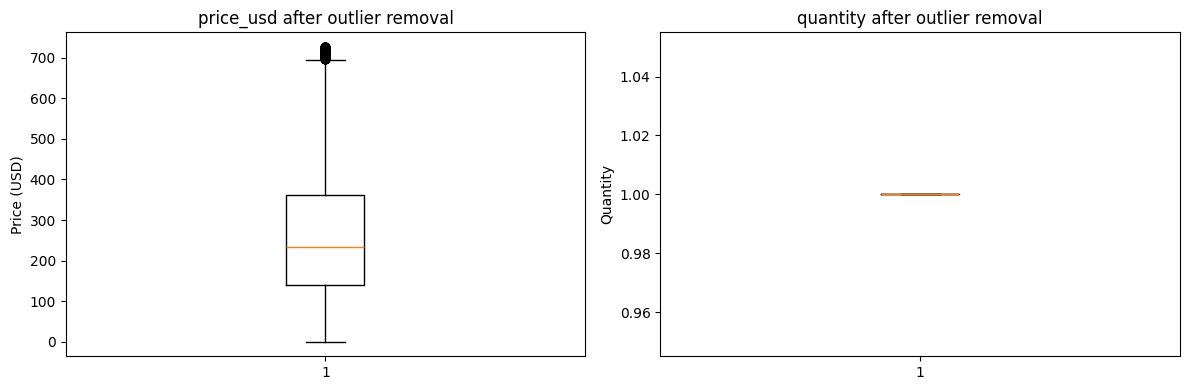

In [39]:
# Outlier Detection (IQR Method)

def remove_outliers_iqr(df, col):
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f"  {col}: removed {before - len(df)} outliers | normal range: {lower:.2f} to {upper:.2f}")
    return df

print("Step 8: Outlier removal (IQR method)")
df = remove_outliers_iqr(df, "price_usd")
df = remove_outliers_iqr(df, "quantity")
print("Shape after outlier removal:", df.shape)
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df["price_usd"])
axes[0].set_title("price_usd after outlier removal")
axes[0].set_ylabel("Price (USD)")

axes[1].boxplot(df["quantity"].astype(float))
axes[1].set_title("quantity after outlier removal")
axes[1].set_ylabel("Quantity")

plt.tight_layout()
plt.show()


In [40]:
# SUMMARY

print("Total rows:      ", len(df))
print("Total columns:   ", len(df.columns))
print("Missing values:  ", df.isnull().sum().sum())
print("Duplicate rows:  ", df.duplicated().sum())
print("Columns:         ", df.columns.tolist())


Total rows:       61669
Total columns:    10
Missing values:   0
Duplicate rows:   0
Columns:          ['purchase_date', 'product_id', 'quantity', 'category', 'gender', 'price_usd', 'customer_id', 'color', 'metal', 'gem']


In [41]:
df.to_csv("jewelry_sales_cleaned.csv", index=False)
print("File saved as: jewelry_sales_cleaned.csv")

from google.colab import files
files.download("jewelry_sales_cleaned.csv")

File saved as: jewelry_sales_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>